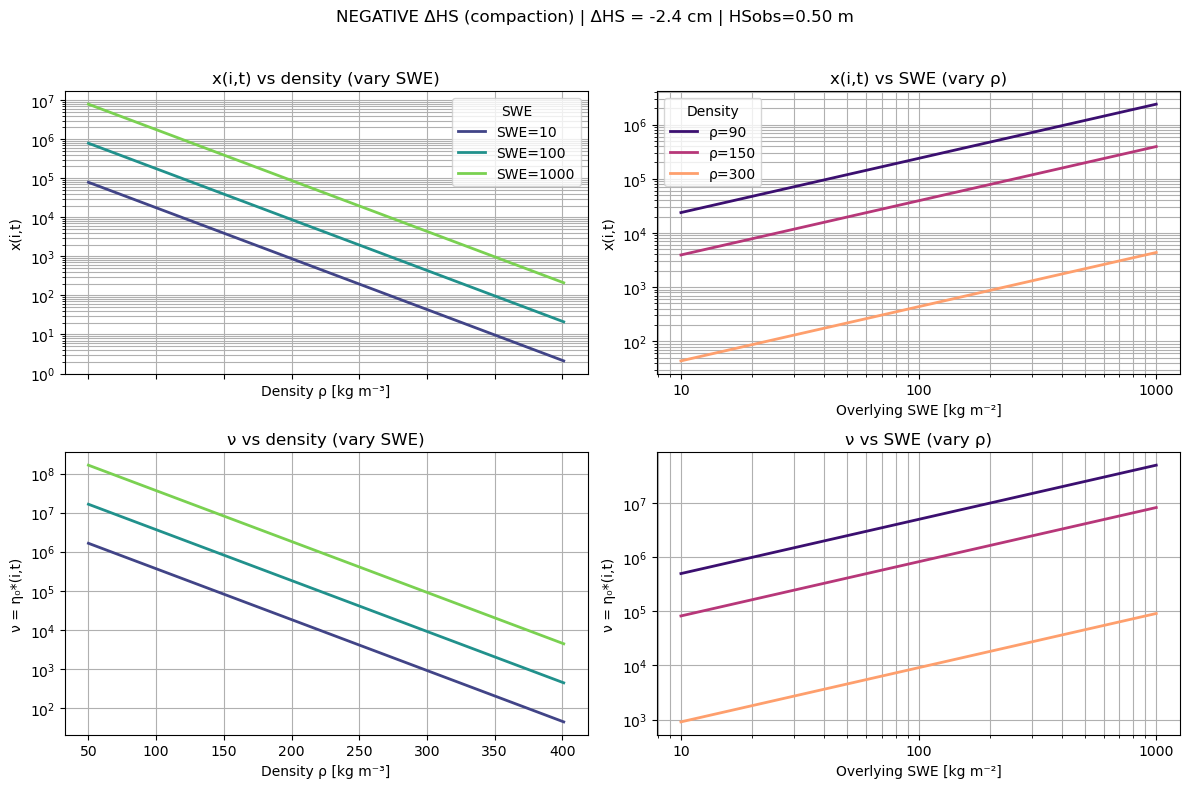

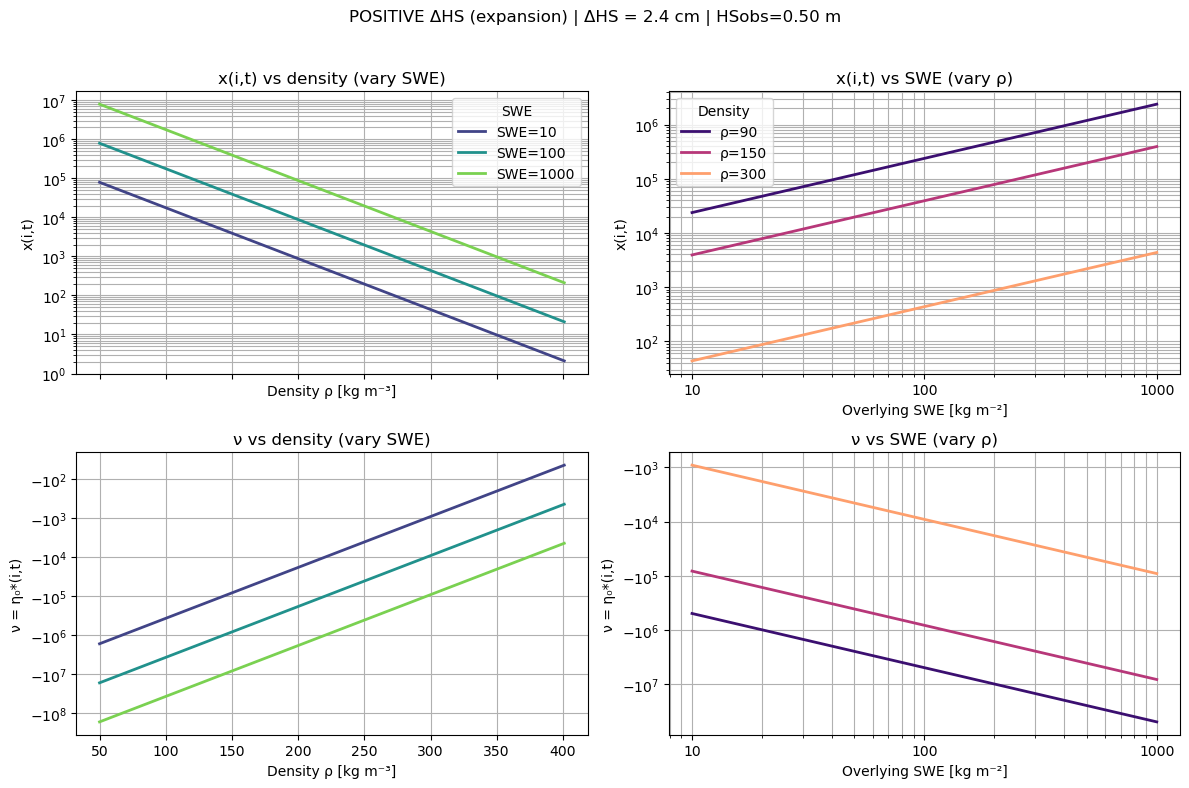

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatter

# ============================================================
# Constants
# ============================================================

g = 9.81
k = 0.030
dt = 3600.0

HSobs = 0.50  # [m]

# Scaling-active cases
dHS_neg = [-0.024]
dHS_pos = [ 0.024]

SWE_cases = [10, 100, 1000]    # [kg m^-2]
rho_cases = [90, 150, 300]     # [kg m^-3]

# Continuous axes
SWE_vals = np.logspace(1, 3, 80)
rho_vals = np.linspace(50, 401, 200)

# ============================================================
# Consistent, modern color maps
# ============================================================

swe_colors = dict(zip(
    SWE_cases,
    plt.cm.viridis(np.linspace(0.2, 0.8, len(SWE_cases)))
))

rho_colors = dict(zip(
    rho_cases,
    plt.cm.magma(np.linspace(0.2, 0.8, len(rho_cases)))
))


def _force_log_xticks(ax, ticks):
    """
    Force log-x ticks/labels to appear (useful with sharex='col').
    """
    ax.set_xscale("log")
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    # Keep minor ticks (optional, looks nicer)
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=12))
    ax.tick_params(axis="x", which="both", labelbottom=True)


def plot_group_one_case(dHS, group_name):
    HSobs_prev = HSobs - dHS
    denom = HSobs_prev - HSobs
    if np.isclose(denom, 0.0):
        raise ValueError("HSobs_prev ≈ HSobs -> singular in Appendix B nu formula.")

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex="col")
    (ax_x_rho, ax_x_swe), (ax_nu_rho, ax_nu_swe) = axes

    # =========================================================
    # (1) x vs density (vary SWE)
    # =========================================================
    for swe in SWE_cases:
        sigma = swe * g
        x_curve = dt * sigma * np.exp(-k * rho_vals)
        ax_x_rho.plot(rho_vals, x_curve, color=swe_colors[swe], lw=2, label=f"SWE={swe}")

    ax_x_rho.set_xlabel("Density ρ [kg m⁻³]")
    ax_x_rho.set_ylabel("x(i,t)")
    ax_x_rho.set_title("x(i,t) vs density (vary SWE)")
    ax_x_rho.set_yscale("log")
    ax_x_rho.grid(True, which="both")

    # =========================================================
    # (2) ν vs density (vary SWE)
    # =========================================================
    for swe in SWE_cases:
        sigma = swe * g
        x_curve = dt * sigma * np.exp(-k * rho_vals)
        nu_curve = x_curve * HSobs / denom
        ax_nu_rho.plot(rho_vals, nu_curve, color=swe_colors[swe], lw=2, label=f"SWE={swe}")

    ax_nu_rho.set_xlabel("Density ρ [kg m⁻³]")
    ax_nu_rho.set_ylabel("ν = η₀*(i,t)")
    ax_nu_rho.set_title("ν vs density (vary SWE)")
    ax_nu_rho.set_yscale("symlog", linthresh=1)
    ax_nu_rho.grid(True, which="both")

    # =========================================================
    # (3) x vs SWE (vary density)
    # =========================================================
    for rho in rho_cases:
        x_curve = dt * (SWE_vals * g) * np.exp(-k * rho)
        ax_x_swe.plot(SWE_vals, x_curve, color=rho_colors[rho], lw=2, label=f"ρ={rho}")

    ax_x_swe.set_xlabel("Overlying SWE [kg m⁻²]")
    ax_x_swe.set_ylabel("x(i,t)")
    ax_x_swe.set_title("x(i,t) vs SWE (vary ρ)")
    ax_x_swe.set_yscale("log")
    _force_log_xticks(ax_x_swe, SWE_cases)
    ax_x_swe.grid(True, which="both")

    # =========================================================
    # (4) ν vs SWE (vary density)
    # =========================================================
    for rho in rho_cases:
        x_curve = dt * (SWE_vals * g) * np.exp(-k * rho)
        nu_curve = x_curve * HSobs / denom
        ax_nu_swe.plot(SWE_vals, nu_curve, color=rho_colors[rho], lw=2, label=f"ρ={rho}")

    ax_nu_swe.set_xlabel("Overlying SWE [kg m⁻²]")
    ax_nu_swe.set_ylabel("ν = η₀*(i,t)")
    ax_nu_swe.set_title("ν vs SWE (vary ρ)")
    ax_nu_swe.set_yscale("symlog", linthresh=1)
    _force_log_xticks(ax_nu_swe, SWE_cases)
    ax_nu_swe.grid(True, which="both")

    # =========================================================
    # Legends
    # =========================================================
    ax_x_rho.legend(title="SWE", frameon=True)
    ax_x_swe.legend(title="Density", frameon=True)

    fig.suptitle(
        f"{group_name} | ΔHS = {dHS*100:.1f} cm | HSobs={HSobs:.2f} m",
        y=0.98
    )

    # Leave room for title + ensure tick labels don't get clipped
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# ============================================================
# Run
# ============================================================
for dHS in dHS_neg:
    plot_group_one_case(dHS, "NEGATIVE ΔHS (compaction)")

for dHS in dHS_pos:
    plot_group_one_case(dHS, "POSITIVE ΔHS (expansion)")

# Example Case

scale = 0.9555555555555555
sum hs_prev = 0.44999999999999996 HSobs_prev = 0.45
sum hs      = 0.43 HSobs      = 0.43


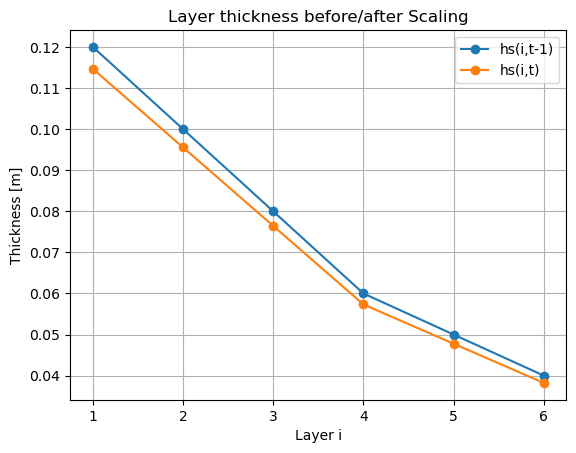

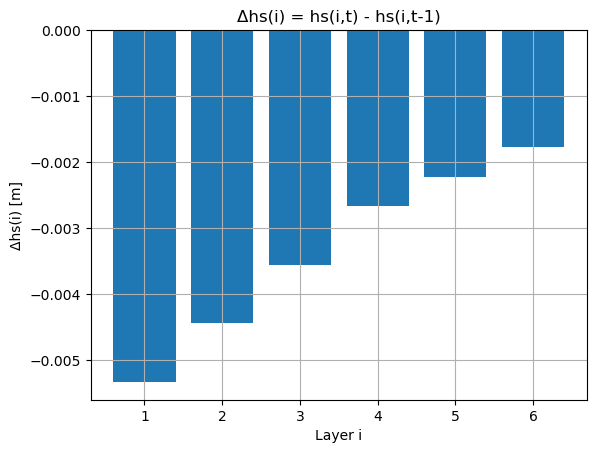

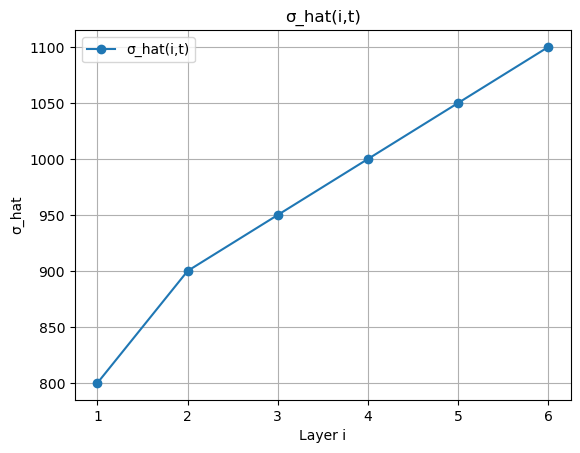

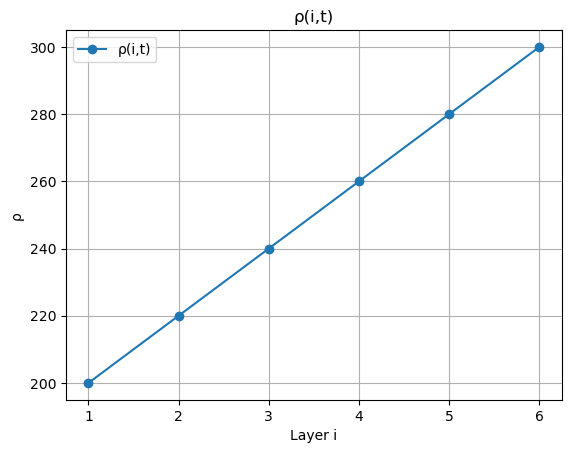

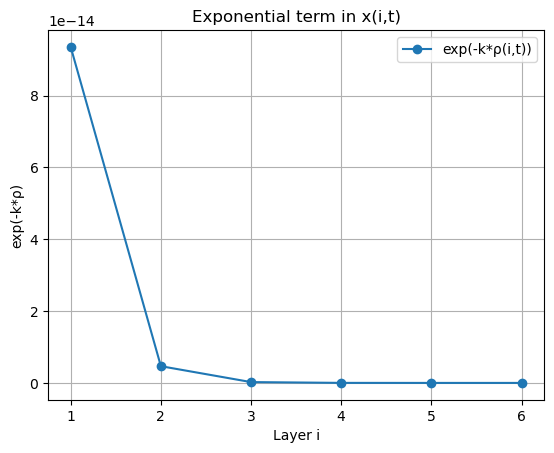

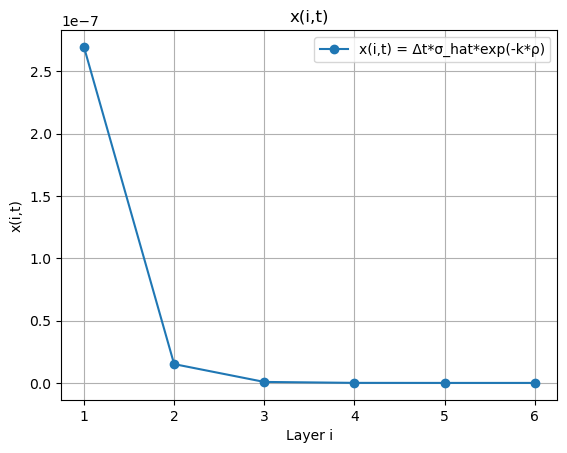

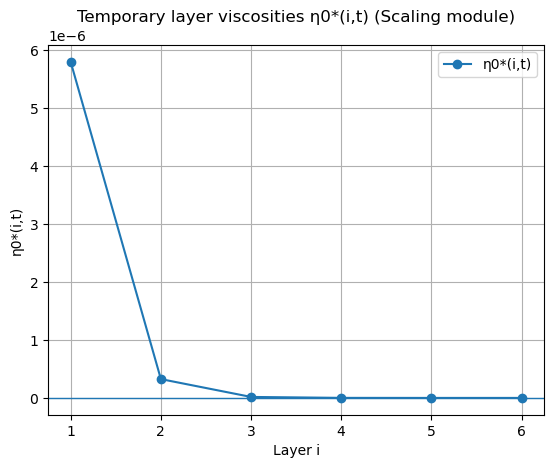

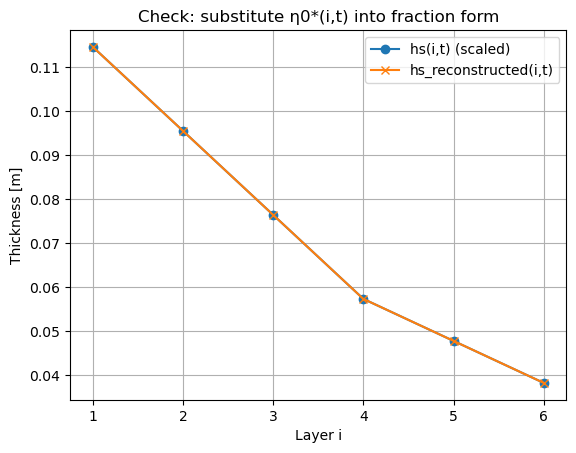

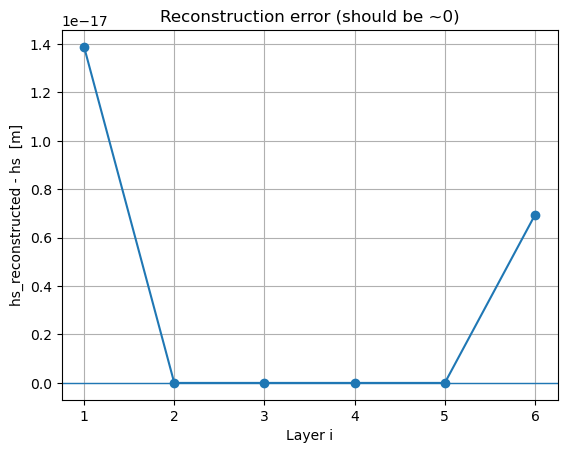

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Appendix B (actual variables from your screenshot)
#
# HS(t) = sum_i hs(i,t)  == HSobs(t)
#
# x(i,t) = Δt * σ_hat(i,t) * exp( -k * ρ(i,t) )
#
# Scaling assumption:
#   hs(i,t) / hs(i,t-1)  ≈  HSobs(t) / HSobs(t-1)
#
# Temporary layer viscosities used in Scaling module:
#   η0*(i,t) = x(i,t) * HSobs(t) / ( HSobs(t-1) - HSobs(t) )
#
# Consistency check (per layer, if you plug η0*(i,t) into Eq. (1)-style fraction):
#   hs_reconstructed(i,t) = η0*(i,t) * hs(i,t-1) / (η0*(i,t) + x(i,t))
# ============================================================


def scaling_module(
    hs_prev,          # hs(i,t-1) [m], shape (L,)
    HSobs_prev,       # HSobs(t-1) [m]
    HSobs,            # HSobs(t) [m]
    dt,               # Δt
    sigma_hat,        # σ_hat(i,t), shape (L,)
    rho,              # ρ(i,t), shape (L,)
    k,                # k
    eps=1e-12,
):
    hs_prev = np.asarray(hs_prev, dtype=float)
    sigma_hat = np.asarray(sigma_hat, dtype=float)
    rho = np.asarray(rho, dtype=float)

    if hs_prev.shape != sigma_hat.shape or hs_prev.shape != rho.shape:
        raise ValueError("hs_prev, sigma_hat, rho must all have the same shape (L,)")

    if abs(HSobs_prev) < eps:
        raise ValueError("HSobs_prev is ~0; cannot compute HSobs/HSobs_prev scaling ratio.")
    if abs(HSobs_prev - HSobs) < eps:
        raise ValueError("HSobs_prev ≈ HSobs; η0*(i,t) formula becomes singular.")

    # Scaling assumption -> layer thicknesses at t
    scale = HSobs / HSobs_prev
    hs = hs_prev * scale
    delta_hs = hs - hs_prev

    # x(i,t) = Δt * σ_hat(i,t) * exp(-k*ρ(i,t))
    exp_term = np.exp(-k * rho)
    x = dt * sigma_hat * exp_term

    # η0*(i,t) = x(i,t) * HSobs(t) / (HSobs(t-1) - HSobs(t))
    eta0_star = x * HSobs / (HSobs_prev - HSobs)

    # Reconstruct hs(i,t) using the fraction form (per-layer substitution)
    hs_reconstructed = (eta0_star * hs_prev) / (eta0_star + x)

    return {
        "scale": scale,
        "hs_prev": hs_prev,
        "hs": hs,
        "delta_hs": delta_hs,
        "sigma_hat": sigma_hat,
        "rho": rho,
        "exp_term": exp_term,
        "x": x,
        "eta0_star": eta0_star,
        "hs_reconstructed": hs_reconstructed,
        "reconstruction_error": hs_reconstructed - hs,
    }


def plot_per_layer(out):
    L = out["hs_prev"].size
    i = np.arange(1, L + 1)

    # 1) hs(i,t-1), hs(i,t), Δhs(i)
    plt.figure()
    plt.plot(i, out["hs_prev"], marker="o", label="hs(i,t-1)")
    plt.plot(i, out["hs"], marker="o", label="hs(i,t)")
    plt.xlabel("Layer i")
    plt.ylabel("Thickness [m]")
    plt.title("Layer thickness before/after Scaling")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    plt.bar(i, out["delta_hs"])
    plt.xlabel("Layer i")
    plt.ylabel("Δhs(i) [m]")
    plt.title("Δhs(i) = hs(i,t) - hs(i,t-1)")
    plt.grid(True)
    plt.show()

    # 2) Terms in x(i,t)
    plt.figure()
    plt.plot(i, out["sigma_hat"], marker="o", label="σ_hat(i,t)")
    plt.xlabel("Layer i")
    plt.ylabel("σ_hat")
    plt.title("σ_hat(i,t)")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(i, out["rho"], marker="o", label="ρ(i,t)")
    plt.xlabel("Layer i")
    plt.ylabel("ρ")
    plt.title("ρ(i,t)")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(i, out["exp_term"], marker="o", label="exp(-k*ρ(i,t))")
    plt.xlabel("Layer i")
    plt.ylabel("exp(-k*ρ)")
    plt.title("Exponential term in x(i,t)")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(i, out["x"], marker="o", label="x(i,t) = Δt*σ_hat*exp(-k*ρ)")
    plt.xlabel("Layer i")
    plt.ylabel("x(i,t)")
    plt.title("x(i,t)")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 3) η0*(i,t)
    plt.figure()
    plt.plot(i, out["eta0_star"], marker="o", label="η0*(i,t)")
    plt.axhline(0.0, linewidth=1.0)
    plt.xlabel("Layer i")
    plt.ylabel("η0*(i,t)")
    plt.title("Temporary layer viscosities η0*(i,t) (Scaling module)")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 4) Reconstruction check: hs_reconstructed vs hs
    plt.figure()
    plt.plot(i, out["hs"], marker="o", label="hs(i,t) (scaled)")
    plt.plot(i, out["hs_reconstructed"], marker="x", label="hs_reconstructed(i,t)")
    plt.xlabel("Layer i")
    plt.ylabel("Thickness [m]")
    plt.title("Check: substitute η0*(i,t) into fraction form")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(i, out["reconstruction_error"], marker="o")
    plt.axhline(0.0, linewidth=1.0)
    plt.xlabel("Layer i")
    plt.ylabel("hs_reconstructed - hs  [m]")
    plt.title("Reconstruction error (should be ~0)")
    plt.grid(True)
    plt.show()


# ============================================================
# EDIT THESE VALUES AND RUN
# ============================================================

# Example: 6 layers
hs_prev = np.array([0.12, 0.10, 0.08, 0.06, 0.05, 0.04])  # hs(i,t-1) [m]

HSobs_prev = 0.45  # HSobs(t-1) [m]  (often equals sum(hs_prev) if already scaled)
HSobs = 0.43       # HSobs(t) [m]

dt = 3600.0        # Δt (e.g., 1 hour in seconds)
k = 0.15

sigma_hat = np.array([800, 900, 950, 1000, 1050, 1100], dtype=float)  # σ_hat(i,t)
rho = np.array([200, 220, 240, 260, 280, 300], dtype=float)           # ρ(i,t)

out = scaling_module(hs_prev, HSobs_prev, HSobs, dt, sigma_hat, rho, k)

print("scale =", out["scale"])
print("sum hs_prev =", out["hs_prev"].sum(), "HSobs_prev =", HSobs_prev)
print("sum hs      =", out["hs"].sum(),      "HSobs      =", HSobs)

plot_per_layer(out)